# Synthetic baseline: EpiLink-Leiden, logistic regression, and TreeCluster

This notebook adds a dated-tree TreeCluster baseline to the matched synthetic experiment.
All methods are evaluated on the same simulated cases and the same overlapping SCoVMod
ground-truth memberships, using BCubed F1 for clustering quality.

| Approach | Input | Clustering operation |
|---|---|---|
| **EpiLink-Leiden** (`EDD`, `EDS`, `ESD`, `ESS`) | compatibility score | weighted graph clustered by Leiden |
| **Logistic regression-Leiden** (`LD`, `LS`) | logistic probability | weighted graph clustered by Leiden |
| **TreeCluster** | time-calibrated phylogeny | dated-tree cut over method and threshold grids |

The TreeCluster workflow mirrors the Boston notebook: a genetic tree is time-calibrated
with TreeTime, then TreeCluster cuts it with thresholds expressed in years. For the
synthetic data, the genetic tree is built from simulated pairwise distances with FastME
instead of from an aligned FASTA with IQ-TREE. Synthetic sampling days are converted to
calendar dates only so TreeTime can fit the molecular clock.

**Comparison protocol**

- The matched-baseline simulation is regenerated with the canonical seed and checked
  against the saved baseline pair count.
- EpiLink and logistic-regression best-F1 values are read from
  `results/synthetic/baseline_performance.json`.
- TreeCluster receives the same oracle-over-grid treatment: the reported score is the
  best BCubed F1 over TreeCluster method and time-threshold grids.
- TreeCluster produces a partition rather than pairwise scores, so AP, PR-Gain, and Brier
  metrics are not applicable to that baseline.

FastME is usually fast at this scale; TreeTime is the main runtime cost. Use `MAX_CASES`
for a small test run, then return it to `None` for comparable results.

## Setup and parameters

In [2]:
import datetime
import io
import json
import subprocess
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score

# Make the evaluation package and its bare-import modules importable.
SRC = Path("src").resolve()
for _p in (str(SRC), str(SRC / "evaluation")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from evaluation.config import build_run_specs, load_config  # noqa: E402
from evaluation.evaluate import _load_tree_template, _reference_memberships  # noqa: E402
from evaluation.models import build_natural_history_parameters, build_linkage_model  # noqa: E402
from evaluation.leiden import build_weighted_graph, run_leiden_partition  # noqa: E402
from evaluation.metrics import bcubed_scores  # noqa: E402
from evaluation.specs import (  # noqa: E402
    PAIRWISE_BOTH_SAMPLED_COLUMN,
    PAIRWISE_CASE_A_COLUMN,
    PAIRWISE_CASE_B_COLUMN,
    PAIRWISE_DETERMINISTIC_DISTANCE_COLUMN,
    PAIRWISE_RELATED_COLUMN,
    PAIRWISE_STOCHASTIC_DISTANCE_COLUMN,
    PAIRWISE_TEMPORAL_DISTANCE_COLUMN,
)
from epilink import (  # noqa: E402
    InfectiousnessToTransmission,
    build_pairwise_case_table,
    simulate_epidemic_dates,
    simulate_genomic_sequences,
)

In [3]:
# ---- paths ----
CONFIG_PATH = "config.yaml"
PERF_JSON = Path("results/synthetic/baseline_performance.json")
OUTDIR = Path("phylo/synthetic")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ---- time calibration (mirrors phylo_cluster_pipeline.ipynb) ----
ORIGIN_DATE = datetime.date(2020, 1, 1)  # calendar anchor for synthetic day 0
CLOCK_FILTER = 0  # IQD temporal-outlier filter; 0 keeps every tip (fair comparison)
CLOCK_RATE = None  # None -> TreeTime infers the clock from root-to-tip regression
CLOCK_STD_DEV = None  # TreeTime's relaxed clock stdev; small value -> strict clock (faster, more comparable to FastME)
# ---- genetic tree (FastME, distance-based) ----
FASTME_METHOD = "N"  # N = neighbour-joining, B = BIONJ

# ---- TreeCluster sweep on the DATED tree (threshold in years) ----
# max_clade caps the within-cluster leaf-to-leaf TIME span; calibrate against known
# epi linkage just as in the Boston notebook (which used 7 / 365).
TC_METHODS = ["max_clade", "avg_clade", "single_linkage"]
TC_THRESHOLD_DAYS = np.arange(7.0, 77.0, 7.0)
TC_THRESHOLDS = TC_THRESHOLD_DAYS / 365.0
SINGLETON_OFFSET = 10**7  # unique cluster ids for TreeCluster's -1 singletons

# ---- method-vs-method similarity (EpiLink-Leiden vs TreeCluster, Step 7) ----
# ARI needs hard partitions, so it compares the two methods to each other, not to the
# overlapping ground truth (which stays on BCubed F1 in Steps 5-6).
LEIDEN_RESOLUTIONS = np.round(np.arange(0.1, 1.01, 0.1), 2)
TC_COMPARE_METHOD = "max_clade"  # TreeCluster method used for the agreement heatmap
MIN_EDGE_WEIGHT = 0.0001  # graph sparsification (matches optimal_thresholds.json)
N_RESTARTS_COMPARE = 5  # Leiden restarts per resolution for the comparison sweep

# ---- quick-iteration knob ----
# Cap the number of cases for a quick test run. Use None for the headline comparison.
MAX_CASES = None

## Step 1 — Reproduce the matched-baseline synthetic data

The simulation is deterministic under the configured seed. Re-running it here recreates
the same sampled cases used by the saved EpiLink and logistic-regression baseline scores.
The populated transmission tree is retained because each sampled case has a `sample_date`
needed for TreeTime calibration.

In [4]:
config = load_config(CONFIG_PATH)
rng_seed = int(config.get("rng_seed", 12345))
runs = build_run_specs(config)
baseline = next(
    r for r in runs if r.condition == "matched" and r.scenario_name == "baseline"
)
gen = baseline.generation_parameters
GENOME_LENGTH = int(gen.get("synthetic_genome_length", 5000))

tree = _load_tree_template(baseline.tree_path).copy()
reference = _reference_memberships(baseline.tree_path)  # ground-truth memberships
profile = InfectiousnessToTransmission(
    parameters=build_natural_history_parameters(gen), rng_seed=rng_seed
)
populated = simulate_epidemic_dates(
    transmission_profile=profile,
    tree=tree,
    fraction_sampled=float(gen.get("fraction_sampled", 1.0)),
)
genomic = simulate_genomic_sequences(
    transmission_profile=profile,
    tree=populated,
    genome_length=GENOME_LENGTH,
)
pairwise = build_pairwise_case_table(genomic["packed"], populated)
pairs = pairwise.loc[pairwise[PAIRWISE_BOTH_SAMPLED_COLUMN]].copy()
print(
    f"{len(pairs):,} sampled pairs | "
    f"prevalence {pairs[PAIRWISE_RELATED_COLUMN].mean():.6f} | "
    f"genome length {GENOME_LENGTH}"
)

12,447,555 sampled pairs | prevalence 0.001447 | genome length 5000


In [5]:
perf = json.loads(PERF_JSON.read_text()) if PERF_JSON.exists() else {}

# Case ids are numeric *strings* in the pairwise table; keep them as strings for
# matrix indexing / filtering (matching the columns) and only int() them when
# scoring against the int-keyed ground-truth reference.
case_ids = np.unique(
    np.concatenate(
        [
            pairs[PAIRWISE_CASE_A_COLUMN].to_numpy(),
            pairs[PAIRWISE_CASE_B_COLUMN].to_numpy(),
        ]
    )
)

if MAX_CASES is not None and MAX_CASES < len(case_ids):
    warnings.warn(
        f"MAX_CASES={MAX_CASES}: TreeCluster results are NOT comparable to the "
        "canonical baseline (computed on all cases). Set MAX_CASES=None for the real run."
    )
    rng = np.random.default_rng(rng_seed)
    case_ids = np.sort(rng.choice(case_ids, size=MAX_CASES, replace=False))
    keep = pairs[PAIRWISE_CASE_A_COLUMN].isin(case_ids) & pairs[
        PAIRWISE_CASE_B_COLUMN
    ].isin(case_ids)
    pairs = pairs.loc[keep].copy()
elif perf:
    expected = int(next(iter(perf.values()))["n_pairs"])
    assert len(pairs) == expected, (
        f"Re-simulated pair count {len(pairs):,} != baseline {expected:,}: "
        "seed/config drift means EpiLink/regression numbers are not comparable."
    )
    print(f"integrity OK: matches canonical baseline ({expected:,} pairs)")

print(f"{len(case_ids):,} cases")

integrity OK: matches canonical baseline (12,447,555 pairs)
4,990 cases


## Step 2 — Build deterministic and stochastic distance matrices

The pairwise table contains deterministic and stochastic genetic distances. This step
converts each long pairwise column into a square symmetric distance matrix over the
sampled cases, matching the data-process axis used by the EpiLink and regression models.

In [6]:
def distance_matrix(pairs, case_ids, dist_col):
    # Densify a long pairwise distance column into a square symmetric matrix.
    # case_ids is sorted, so searchsorted gives exact row/col positions.
    ia = np.searchsorted(case_ids, pairs[PAIRWISE_CASE_A_COLUMN].to_numpy())
    ib = np.searchsorted(case_ids, pairs[PAIRWISE_CASE_B_COLUMN].to_numpy())
    d = pairs[dist_col].to_numpy(dtype=float)
    n = len(case_ids)
    M = np.zeros((n, n), dtype=float)
    M[ia, ib] = d
    M[ib, ia] = d
    return M


DIST_COLS = {
    "deterministic": PAIRWISE_DETERMINISTIC_DISTANCE_COLUMN,
    "stochastic": PAIRWISE_STOCHASTIC_DISTANCE_COLUMN,
}
matrices = {
    name: distance_matrix(pairs, case_ids, col) for name, col in DIST_COLS.items()
}
for name, M in matrices.items():
    print(f"{name:13s} {M.shape}  range [{M.min():.0f}, {M.max():.0f}]")

deterministic (4990, 4990)  range [0, 49]
stochastic    (4990, 4990)  range [0, 52]


## Step 3 — Build FastME trees and TreeTime date metadata

FastME builds a distance-based genetic tree for each distance matrix. Distances are scaled
to substitutions per site (`SNP distance / genome length`) so TreeTime can interpret the
branch lengths as sequence divergence.

The synthetic `sample_date` values are days since the epidemic origin. They are converted
to ISO calendar dates and written as the `name,date` table required by TreeTime.

In [7]:
def fastme_tree(D, labels, scale, workdir, method="N"):
    # Build a distance tree with FastME (scales to thousands of tips).
    # The matrix is scaled to substitutions/site (SNP / genome length) so the
    # resulting branch lengths are divergence, which TreeTime reads directly.
    workdir = Path(workdir)
    workdir.mkdir(parents=True, exist_ok=True)
    phylip = workdir / "distances.phy"
    tree = workdir / "fastme.nwk"
    scaled = D * scale
    with open(phylip, "w") as handle:  # stream rows to keep memory bounded
        handle.write(f"{len(labels)}\n")
        for i, label in enumerate(labels):
            handle.write(f"{label} ")
            np.savetxt(handle, scaled[i : i + 1], fmt="%.8f")
    subprocess.run(
        ["fastme", "-i", str(phylip), "-o", str(tree), "-m", method],
        capture_output=True,
        text=True,
        check=True,
    )
    return tree


def write_dates(case_ids, populated, origin, path):
    # Convert per-case sample_date (days since origin) to calendar dates for TreeTime.
    names, dates = [], []
    for case_id in case_ids:
        sample_day = populated.nodes[str(case_id)].get("sample_date")
        if sample_day is None:
            continue
        calendar = origin + datetime.timedelta(days=int(round(float(sample_day))))
        names.append(str(case_id))
        dates.append(calendar.isoformat())
    frame = pd.DataFrame({"name": names, "date": dates})
    frame.to_csv(path, index=False)
    return frame


dates_csv = OUTDIR / "dates.csv"
dates_frame = write_dates(case_ids, populated, ORIGIN_DATE, dates_csv)
print(
    f"{len(dates_frame)} dated tips: "
    f"{dates_frame['date'].min()} .. {dates_frame['date'].max()}"
)

# FastME (~minutes per tree at ~5000 tips) is reused if already built. Caching only
# applies to the canonical run; any MAX_CASES subsample always rebuilds.
genetic_newicks = {}
for name, M in matrices.items():
    cached = OUTDIR / f"fastme_{name}" / "fastme.nwk"
    if cached.exists() and MAX_CASES is None:
        genetic_newicks[name] = cached
        print(f"{name:13s} FastME tree (cached) -> {cached}")
        continue
    t0 = time.time()
    genetic_newicks[name] = fastme_tree(
        M, case_ids, 1.0 / GENOME_LENGTH, OUTDIR / f"fastme_{name}", FASTME_METHOD
    )
    print(
        f"{name:13s} FastME tree -> {genetic_newicks[name]}  ({time.time() - t0:.0f}s)"
    )

4990 dated tips: 2020-01-18 .. 2020-07-14
deterministic FastME tree (cached) -> phylo/synthetic/fastme_deterministic/fastme.nwk
stochastic    FastME tree (cached) -> phylo/synthetic/fastme_stochastic/fastme.nwk


## Step 4 — Time-calibrate the FastME trees with TreeTime

TreeTime fits the molecular clock and rescales the FastME branch lengths into calendar
years. The dated NEXUS trees are then converted to Newick with `gotree`, matching the
format expected by TreeCluster.

In [8]:
def time_calibrate(
    genetic_nwk, dates_csv, outdir, seq_length, clock_filter, clock_rate, clock_std_dev
):
    # NJ genetic tree (+ dates) -> TreeTime dated tree -> Newick (years).
    outdir = Path(outdir)
    cmd = [
        "treetime",
        "--tree",
        str(genetic_nwk),
        "--dates",
        str(dates_csv),
        "--sequence-length",
        str(int(seq_length)),
        "--clock-filter",
        str(clock_filter),
        "--outdir",
        str(outdir),
    ]
    if clock_rate is not None:
        cmd += ["--clock-rate", str(clock_rate)]
    if clock_std_dev is not None:
        cmd += ["--clock-std-dev", str(clock_std_dev)]
    subprocess.run(cmd, capture_output=True, text=True, check=True)
    nexus = outdir / "timetree.nexus"
    newick = outdir / "timetree.nwk"
    subprocess.run(
        [
            "gotree",
            "reformat",
            "newick",
            "-i",
            str(nexus),
            "-f",
            "nexus",
            "-o",
            str(newick),
        ],
        capture_output=True,
        text=True,
        check=True,
    )
    return newick


# TreeTime (~minutes per tree) is reused if already calibrated. Caching only applies to
# the canonical run; any MAX_CASES subsample always recalibrates.
dated_newicks = {}
for name, genetic_nwk in genetic_newicks.items():
    dated_path = OUTDIR / f"treetime_{name}" / "timetree.nwk"
    if dated_path.exists() and MAX_CASES is None:
        dated_newicks[name] = dated_path
        print(f"{name:13s} dated tree (cached) -> {dated_path}")
        continue
    t0 = time.time()
    dated = time_calibrate(
        genetic_nwk,
        dates_csv,
        OUTDIR / f"treetime_{name}",
        GENOME_LENGTH,
        CLOCK_FILTER,
        CLOCK_RATE,
        CLOCK_STD_DEV,
    )
    dated_newicks[name] = dated
    clock = OUTDIR / f"treetime_{name}" / "molecular_clock.txt"
    rate = clock.read_text().strip().splitlines() if clock.exists() else []
    print(f"{name:13s} dated tree -> {dated}  ({time.time() - t0:.0f}s)")
    for line in rate:
        if "rate" in line or "r^2" in line:
            print("   ", line.strip())

deterministic dated tree (cached) -> phylo/synthetic/treetime_deterministic/timetree.nwk
stochastic    dated tree (cached) -> phylo/synthetic/treetime_stochastic/timetree.nwk


## Step 5 — Sweep TreeCluster methods and thresholds

TreeCluster is run over each dated tree, each method in `TC_METHODS`, and each threshold
in `TC_THRESHOLD_DAYS`. Every partition is scored against the overlapping SCoVMod ground
truth with BCubed precision, recall, and F1. TreeCluster singletons (`-1`) are converted
to unique singleton clusters for scoring.

In [9]:
def run_treecluster(newick_path, threshold, method):
    proc = subprocess.run(
        ["TreeCluster.py", "-i", str(newick_path), "-t", str(threshold), "-m", method],
        capture_output=True,
        text=True,
        check=True,
    )
    df = pd.read_csv(io.StringIO(proc.stdout), sep="\t")
    df.columns = ["SequenceName", "ClusterNumber"]
    return df


def treecluster_memberships(df):
    # Map TreeCluster output to {case_id: {cluster_id}}; -1 -> unique singleton.
    pred = {}
    singleton = SINGLETON_OFFSET
    for name, cid in zip(df["SequenceName"], df["ClusterNumber"]):
        cid = int(cid)
        if cid == -1:
            pred[int(name)] = {singleton}
            singleton += 1
        else:
            pred[int(name)] = {cid}
    return pred


sweep_path = OUTDIR / "treecluster_sweep.parquet"
if sweep_path.exists() and MAX_CASES is None:
    print(f"TreeCluster sweep (cached) -> {sweep_path}")
    sweep = pd.read_parquet(sweep_path)
    print(f"{len(sweep)} (data process × method × threshold) evaluations")
    sweep.sort_values("bcubed_f1", ascending=False).head(10)
else:
    rows = []
    for name, path in dated_newicks.items():
        for method in TC_METHODS:
            for t_years, t_days in zip(TC_THRESHOLDS, TC_THRESHOLD_DAYS):
                df = run_treecluster(path, float(t_years), method)
                try:
                    precision, recall, f1 = bcubed_scores(
                        treecluster_memberships(df), reference
                    )
                except ValueError:
                    continue
                clustered = df["ClusterNumber"] != -1
                rows.append(
                    {
                        "data_process": name,
                        "method": method,
                        "threshold_days": float(t_days),
                        "threshold_years": float(t_years),
                        "bcubed_precision": precision,
                        "bcubed_recall": recall,
                        "bcubed_f1": f1,
                        "n_clusters": int(df.loc[clustered, "ClusterNumber"].nunique()),
                        "n_singletons": int((~clustered).sum()),
                    }
                )

    sweep = pd.DataFrame(rows)
    sweep.to_parquet(OUTDIR / "treecluster_sweep.parquet", index=False)
    print(f"{len(sweep)} (data process × method × threshold) evaluations")
    sweep.sort_values("bcubed_f1", ascending=False).head(10)

60 (data process × method × threshold) evaluations


,data_process,method,threshold_days,threshold_years,bcubed_precision,bcubed_recall,bcubed_f1,n_clusters,n_singletons
42,stochastic,avg_clade,21.0,0.057534,0.596290,0.583874,0.590017,622,1529
35,stochastic,max_clade,42.0,0.115068,0.578766,0.600612,0.589487,643,1385
3,deterministic,max_clade,28.0,0.076712,0.590972,0.584976,0.587959,900,932
4,deterministic,max_clade,35.0,0.095890,0.521781,0.670650,0.586923,767,586
34,stochastic,max_clade,35.0,0.095890,0.637620,0.542109,0.585998,694,1700
36,stochastic,max_clade,49.0,0.134247,0.524789,0.653302,0.582036,582,1143
51,stochastic,single_linkage,14.0,0.038356,0.650648,0.525125,0.581186,595,1938
11,deterministic,avg_clade,14.0,0.038356,0.628452,0.534281,0.577553,917,1267
43,stochastic,avg_clade,28.0,0.076712,0.483403,0.693123,0.569571,503,1013
33,stochastic,max_clade,28.0,0.076712,0.702646,0.477055,0.568281,747,2103


## Step 6 — Summarize baseline clustering performance

This table combines the saved EpiLink/logistic-regression Leiden results with the best
TreeCluster result for each data process. The comparison is restricted to clustering
quality, because TreeCluster does not produce pairwise rankings.

In [10]:
tc_best = (
    sweep.sort_values("bcubed_f1", ascending=False)
    .groupby("data_process", as_index=False)
    .first()
)
tc_rows = [
    {
        "model": f"TreeCluster ({row.data_process})",
        "family": "TreeCluster",
        "data_process": row.data_process,
        "clustering": "tree-cut (dated)",
        "best_f1": row.bcubed_f1,
        "detail": f"{row.method} @ {row.threshold_days:g}d",
        "ap": np.nan,
    }
    for row in tc_best.itertuples()
]

EPILINK = {"EDD", "EDS", "ESD", "ESS"}
DATA_PROC = {
    "EDD": "deterministic",
    "ESD": "deterministic",
    "LD": "deterministic",
    "EDS": "stochastic",
    "ESS": "stochastic",
    "LS": "stochastic",
}
pw_rows = [
    {
        "model": key,
        "family": "EpiLink" if key in EPILINK else "Logistic regression",
        "data_process": DATA_PROC[key],
        "clustering": "Leiden",
        "best_f1": value["best_f1"],
        "detail": f"AP={value['ap']:.3f}",
        "ap": value["ap"],
    }
    for key, value in perf.items()
]

comparison = (
    pd.DataFrame(pw_rows + tc_rows)
    .sort_values("best_f1", ascending=False)
    .reset_index(drop=True)
)
comparison.to_parquet(OUTDIR / "treecluster_comparison.parquet", index=False)
comparison

,model,family,data_process,clustering,best_f1,detail,ap
0,LD,Logistic regression,deterministic,Leiden,0.647290,AP=0.568,0.567922
1,ESD,EpiLink,deterministic,Leiden,0.643841,AP=0.469,0.469325
2,EDD,EpiLink,deterministic,Leiden,0.629347,AP=0.300,0.299579
3,TreeCluster (stochastic),TreeCluster,stochastic,tree-cut (dated),0.590017,avg_clade @ 21d,NaN
4,TreeCluster (deterministic),TreeCluster,deterministic,tree-cut (dated),0.587959,max_clade @ 28d,NaN
5,LS,Logistic regression,stochastic,Leiden,0.572059,AP=0.275,0.275356
6,ESS,EpiLink,stochastic,Leiden,0.558696,AP=0.190,0.190371
7,EDS,EpiLink,stochastic,Leiden,0.495397,AP=0.090,0.090462


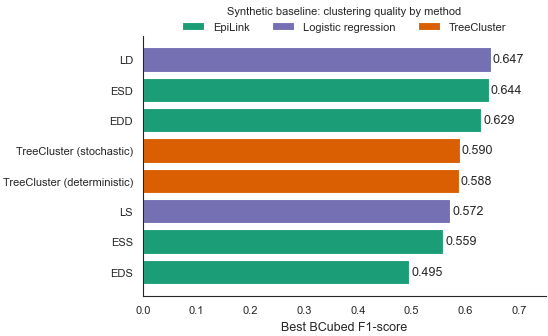

In [16]:
from matplotlib.patches import Patch
from evaluation.plotting import (
    PLOS_WIDTHS_CM,
    cm_to_inch,
    save_plos_figure,
    set_plos_theme,
    add_panel_labels,
)

set_plos_theme()

fig, ax = plt.subplots(
    figsize=(
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]) * 0.65,
    )
)
palette = {
    "EpiLink": "#1b9e77",
    "Logistic regression": "#7570b3",
    "TreeCluster": "#d95f02",
}
ordered = comparison.sort_values("best_f1")
ax.barh(
    ordered["model"], ordered["best_f1"], color=[palette[f] for f in ordered["family"]]
)
ax.set_xlabel("Best BCubed F1-score")
for y, (value, detail) in enumerate(zip(ordered["best_f1"], ordered["detail"])):
    ax.text(value + 0.004, y, f"{value:.3f}", va="center")

ax.set_xlim(0, 0.75)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)

handles = [Patch(facecolor=c) for c in palette.values()]
ax.legend(
    handles, 
    palette.keys(),
    title="Synthetic baseline: clustering quality by method",
    ncol=3, 
    loc="upper center", 
    bbox_to_anchor=(0.5, 1.15),
    )

_ = save_plos_figure(
    fig, 
    "treecluster_comparison", 
    out_dir=OUTDIR,
    save_pdf=True,
    save_png=True,
    save_tiff=True,
    save_eps=False,
    )

## Step 7 — Compare EpiLink-Leiden and TreeCluster partitions

ARI and AMI require hard, non-overlapping partitions, so they are not appropriate for the
overlapping SCoVMod reference. This step instead measures agreement between EpiLink-Leiden
and TreeCluster across the Leiden resolution × TreeCluster threshold grid.

- EpiLink scores pairs with the matched-baseline stochastic scorer for each data process,
  builds the sparsified graph, and runs multi-restart Leiden.
- TreeCluster cuts the dated tree with `TC_COMPARE_METHOD` at each threshold.
- Metrics are computed on shared cases only, with TreeCluster singletons mapped to unique
  labels.

In [12]:
# EpiLink-Leiden partitions per data process across the resolution grid.
epilink_model = build_linkage_model(
    baseline.inference_parameters, mutation_process="stochastic", rng_seed=rng_seed
)
temporal = pairs[PAIRWISE_TEMPORAL_DISTANCE_COLUMN].to_numpy()
source_ids = pairs[PAIRWISE_CASE_A_COLUMN].to_numpy()
target_ids = pairs[PAIRWISE_CASE_B_COLUMN].to_numpy()

leiden_partitions = {}  # {data_process: {resolution: {case_id: cluster}}}
for name, col in DIST_COLS.items():
    scores = np.asarray(
        epilink_model.score_target(
            sample_time_difference=temporal, genetic_distance=pairs[col].to_numpy()
        ),
        dtype=float,
    )
    graph = build_weighted_graph(
        minimum_weight=MIN_EDGE_WEIGHT,
        source_ids=source_ids,
        target_ids=target_ids,
        weights=scores,
        vertex_ids=case_ids,
    )
    per_resolution = {}
    for resolution in LEIDEN_RESOLUTIONS:
        partition, _ = run_leiden_partition(
            graph,
            "weight",
            float(resolution),
            num_restarts=N_RESTARTS_COMPARE,
            rng_seed=rng_seed,
        )
        per_resolution[float(resolution)] = {
            graph.vs[i]["case_id"]: partition.membership[i]
            for i in range(graph.vcount())
        }
    leiden_partitions[name] = per_resolution
    counts = [len(set(per_resolution[float(r)].values())) for r in LEIDEN_RESOLUTIONS]
    print(f"{name:13s} EpiLink-Leiden: {graph.ecount():,} edges | clusters {counts}")

# TreeCluster partitions per data process across the threshold grid (compare method).
# SequenceName is cast to str: numeric case ids would otherwise be read as int64 and
# fail to match the string-keyed Leiden / case_ids.
tc_partitions = {}  # {data_process: {threshold_days: {case_id: cluster}}}
for name, dated in dated_newicks.items():
    per_threshold = {}
    for t_days, t_years in zip(TC_THRESHOLD_DAYS, TC_THRESHOLDS):
        df = run_treecluster(dated, float(t_years), TC_COMPARE_METHOD)
        per_threshold[float(t_days)] = dict(
            zip(df["SequenceName"].astype(str), df["ClusterNumber"].astype(int))
        )
    tc_partitions[name] = per_threshold
print(f"TreeCluster partitions: {TC_COMPARE_METHOD} at {len(TC_THRESHOLD_DAYS)} thresholds")

deterministic EpiLink-Leiden: 1,154,228 edges | clusters [552, 897, 1206, 1578, 2010, 2641, 3514, 4539, 4990, 4990]
stochastic    EpiLink-Leiden: 1,630,609 edges | clusters [637, 962, 1208, 1488, 1839, 2492, 3272, 4334, 4990, 4990]
TreeCluster partitions: max_clade at 10 thresholds


In [ ]:
def _label_vector(partition, shared):
    # Hard-label vector over `shared`; each -1 becomes a unique singleton label.
    labels, singleton = [], 10**9
    for sample in shared:
        cluster = partition.get(sample, -1)
        if cluster == -1:
            labels.append(singleton)
            singleton += 1
        else:
            labels.append(cluster)
    return labels

similarity = {}  # {data_process: {"ari": DataFrame, "ami": DataFrame}}
res_cols = [f"{r:g}" for r in LEIDEN_RESOLUTIONS]
thr_rows = [f"{d:g}" for d in TC_THRESHOLD_DAYS]
for name in DIST_COLS:
    ari_path = OUTDIR / f"method_similarity_ari_{name}.csv"
    ami_path = OUTDIR / f"method_similarity_ami_{name}.csv"
    if ari_path.exists() and ami_path.exists() and MAX_CASES is None:
        print(f"{name:13s} method similarity (cached) -> {ari_path}, {ami_path}")
        similarity[name] = {
            "ari": pd.read_csv(ari_path, index_col=0),
            "ami": pd.read_csv(ami_path, index_col=0),
        }
        continue
    leiden = leiden_partitions[name]
    treecluster = tc_partitions[name]
    shared = sorted(set(map(str, case_ids)) & set(next(iter(treecluster.values()))))
    leiden_lab = {r: _label_vector(leiden[float(r)], shared) for r in LEIDEN_RESOLUTIONS}
    ari = pd.DataFrame(index=thr_rows, columns=res_cols, dtype=float)
    ami = pd.DataFrame(index=thr_rows, columns=res_cols, dtype=float)
    for days in TC_THRESHOLD_DAYS:
        tc_lab = _label_vector(treecluster[float(days)], shared)
        for r in LEIDEN_RESOLUTIONS:
            ari.loc[f"{days:g}", f"{r:g}"] = adjusted_rand_score(tc_lab, leiden_lab[r])
            ami.loc[f"{days:g}", f"{r:g}"] = adjusted_mutual_info_score(tc_lab, leiden_lab[r])
    similarity[name] = {"ari": ari, "ami": ami}
    ari.to_csv(OUTDIR / f"method_similarity_ari_{name}.csv")
    ami.to_csv(OUTDIR / f"method_similarity_ami_{name}.csv")
    print(
        f"{name:13s} ({len(shared)} shared cases)  "
        f"ARI {ari.to_numpy().min():.3f}..{ari.to_numpy().max():.3f}  "
        f"AMI {ami.to_numpy().min():.3f}..{ami.to_numpy().max():.3f}"
    )

deterministic (4990 shared cases)  ARI 0.000..0.445  AMI 0.000..0.731
stochastic    (4990 shared cases)  ARI 0.000..0.288  AMI 0.000..0.608


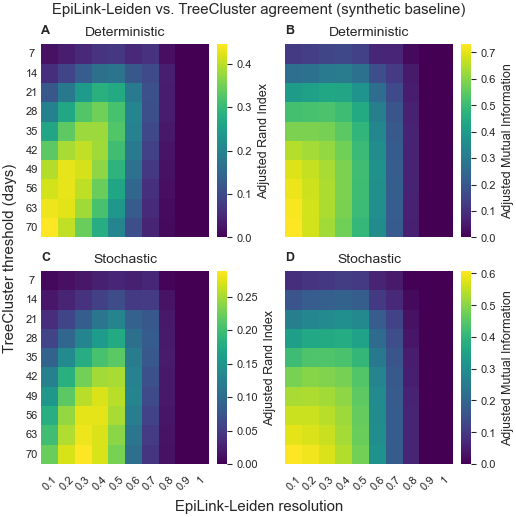

In [15]:
n_processes = len(DIST_COLS)
set_plos_theme()

fig, axes = plt.subplots(
    n_processes, 2,
    figsize=(
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
        cm_to_inch(PLOS_WIDTHS_CM["text_column"]),
    ),
    sharex=True,
    sharey=True,
    layout="constrained",
)

for row, name in enumerate(DIST_COLS):
    for col, (metric, label) in enumerate(
        [("ari", "Adjusted Rand Index"), ("ami", "Adjusted Mutual Information")]
    ):
        ax = axes[row][col]
        sns.heatmap(
            similarity[name][metric],
            cmap="viridis",
            vmin=0,
            cbar_kws={"label": label},
            ax=ax,
        )
        ax.set_title(f"{name.capitalize()}")
for ax in axes[1, 0:].ravel():
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="center")

for ax in axes[0:, 0].ravel():
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, ha="center")

fig.supxlabel("EpiLink-Leiden resolution")
fig.supylabel("TreeCluster threshold (days)")
fig.suptitle("EpiLink-Leiden vs. TreeCluster agreement (synthetic baseline)")

add_panel_labels(axes.ravel())
_ = save_plos_figure(
    fig, 
    "method_similarity_synthetic", 
    out_dir=OUTDIR,
    save_pdf=True,
    save_png=True,
    save_tiff=True,
    save_eps=False,
    )

## Notes and interpretation

- **Time calibration.** TreeCluster thresholds are clade time depths in years; rows are
  labeled in days for readability.
- **Clock signal.** TreeTime infers the molecular clock by root-to-tip regression. If the
  synthetic temporal signal is weak, set `CLOCK_RATE` to the known simulation rate.
- **Caching.** With `MAX_CASES is None`, existing FastME and TreeTime outputs under
  `phylo/synthetic/` are reused. Delete those folders to force a rebuild.
- **Ground truth versus method agreement.** BCubed F1 scores each method against the
  overlapping SCoVMod ground truth. ARI and AMI are used only to compare EpiLink-Leiden
  and TreeCluster to each other.
- **Metric scope.** AP, PR-Gain, and Brier score require pairwise rankings, which
  TreeCluster does not provide.
- **Oracle-over-grid.** Best-F1 is selected over a tuning grid for every method: Leiden
  resolution for EpiLink/regression and TreeCluster method plus threshold for TreeCluster.
- **Interpretation.** This analysis isolates the clustering paradigm by comparing graph
  community detection with dated-tree cutting. Building trees from simulated alignments
  would add a separate tree-inference-error ablation.